### Опционы для умного инвестора

https://dzen.ru/id/5f6b2336d03ed90da6bf9d00


In [79]:
import pandas as pd
from chart_studio import plotly 

from plotly import graph_objs as go
from plotly.offline import iplot, init_notebook_mode
import plotly.express as px

import option_pricer

init_notebook_mode(connected=True)

pd.set_option("display.max_rows", 20, "display.max_columns", 30)

In [98]:
from importlib import reload
reload(option_pricer)

<module 'option_pricer' from '/home/akumidv/Workspace/trade/study-trading/Option_and_futures/option_code/option_pricer.py'>

In [81]:
OPT_DATA_PATH='./_data/options_clean/COM.BRN/2024.parquet'
df_opt = pd.read_parquet(OPT_DATA_PATH).rename(columns={'underlying': 'underlying_price', 'futures_expiration_date': 'underlying_expiration_date', 'value': 'premium'})
len(df_opt['datetime'].unique())

249

In [89]:
df_opt = option_pricer.add_intrinsic_and_time_value(df_opt)
df_opt.head(2)

,datetime,expiration_date,contract_month,strike,mny,log_mny,type,premium,volume,open_interest,underlying_price,dte,tte,iv,delta,...,vega,theta,rate,futures_symbol,future_id,underlying_expiration_date,year,mny_sd,settle,iv_settle,sd,root_id,contact_size,intrinsic_value,time_value
0,2024-12-13,2024-12-23,25G,250.0,3.356155,1.210796,c,1.136696e-37,0,0,74.49,10,0.027397,0.572627,2.089068e-37,...,3.298632e-37,-9.578175e-37,0.04407,BRN25G,COM.BRN/G25,2024-12-30,NaN,57.136889,0.010000,2.297535,NaN,COM.BRN_BRN,1000.0,0.00,1.136696e-37
1,2024-12-13,2024-12-23,25G,250.0,3.356155,1.210796,p,1.755100e+02,0,0,74.49,10,0.027397,0.572627,-1.000000e+00,...,0.000000e+00,-0.000000e+00,0.04407,BRN25G,COM.BRN/G25,2024-12-30,NaN,57.136889,175.509995,0.729311,NaN,COM.BRN_BRN,1000.0,175.51,2.136230e-06


In [90]:
df_opt['money_status'] = get_atm_itm_otm(df_opt)
df_opt[df_opt['money_status']==option_pricer.OptionMoneyStatus.ATM.code].head(2)

/tmp/ipykernel_446967/2387544283.py:22: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,datetime,expiration_date,contract_month,strike,mny,log_mny,type,premium,volume,open_interest,underlying_price,dte,tte,iv,delta,...,theta,rate,futures_symbol,future_id,underlying_expiration_date,year,mny_sd,settle,iv_settle,sd,root_id,contact_size,intrinsic_value,time_value,money_status
194,2024-12-13,2024-12-23,25G,74.5,1.000134,0.000134,c,1.221633,813,4156,74.49,10,0.027397,0.249375,0.506936,...,-0.061322,0.04407,BRN25G,COM.BRN/G25,2024-12-30,NaN,0.003256,1.22,0.249134,NaN,COM.BRN_BRN,1000.0,0.00,1.221633,atm
195,2024-12-13,2024-12-23,25G,74.5,1.000134,0.000134,p,1.231635,240,837,74.49,10,0.027397,0.249375,-0.493064,...,-0.061322,0.04407,BRN25G,COM.BRN/G25,2024-12-30,NaN,0.003256,1.23,0.249134,NaN,COM.BRN_BRN,1000.0,0.01,1.221635,atm


In [91]:
settlement_date = df_opt['datetime'].max()
df_opt_date = df_opt[df_opt['datetime']==settlement_date]
list(df_opt_date['expiration_date'].unique())[:5]

[datetime.date(2024, 12, 23),
 datetime.date(2025, 1, 28),
 datetime.date(2025, 2, 25),
 datetime.date(2025, 3, 26),
 datetime.date(2025, 4, 25)]

In [92]:
expiration_date = df_opt_date['expiration_date'].min()
settlement_date, expiration_date

(datetime.date(2024, 12, 13), datetime.date(2024, 12, 23))

In [104]:
df_opt_chain = df_opt_date[df_opt_date['expiration_date']==expiration_date]
df_opt_chain.head(2)

,datetime,expiration_date,contract_month,strike,mny,log_mny,type,premium,volume,open_interest,underlying_price,dte,tte,iv,delta,...,theta,rate,futures_symbol,future_id,underlying_expiration_date,year,mny_sd,settle,iv_settle,sd,root_id,contact_size,intrinsic_value,time_value,money_status
0,2024-12-13,2024-12-23,25G,250.0,3.356155,1.210796,c,1.136696e-37,0,0,74.49,10,0.027397,0.572627,2.089068e-37,...,-9.578175e-37,0.04407,BRN25G,COM.BRN/G25,2024-12-30,NaN,57.136889,0.010000,2.297535,NaN,COM.BRN_BRN,1000.0,0.00,1.136696e-37,otm
1,2024-12-13,2024-12-23,25G,250.0,3.356155,1.210796,p,1.755100e+02,0,0,74.49,10,0.027397,0.572627,-1.000000e+00,...,-0.000000e+00,0.04407,BRN25G,COM.BRN/G25,2024-12-30,NaN,57.136889,175.509995,0.729311,NaN,COM.BRN_BRN,1000.0,175.51,2.136230e-06,itm


Типы фьючерсов:
* Валютные
* Индексные
* Товарные
* Фондовые
* Процентные
  
  Криптовалютные?? отдельный тип или это валютные?


Спецификация WTI https://www.cmegroup.com/markets/energy/crude-oil/light-sweet-crude.html
https://www.investing.com/commodities/crude-oil - график

In [118]:
atm_nearest_strikes = option_pricer.get_chain_atm_nearest_strikes(df_opt_chain)
atm_strike = atm_nearest_strikes[0]
atm_strike

np.float64(74.5)

In [106]:
# options chain / desk
df_opt_desk = option_pricer.prepare_desk(df_opt_chain, ['premium', 'iv' , 'delta', 'gamma', 'vega', 'theta', 'quick_delta', 'money_status', 'intrinsic_value', 'time_value', 'datetime', 'expiration_date', 'strike'])
res_col = ['premium_call', 'iv_call', 'delta_call', 'gamma_call', 'vega_call', 'theta_call', 'quick_delta_call', 'intrinsic_value_call', 'time_value_call', 'money_status_call', 'strike', 'money_status_put','premium_put', 'iv_put', 'delta_put', 'gamma_put', 'vega_put', 'theta_put', 'quick_delta_put', 'intrinsic_value_put', 'time_value_put', 'datetime', 'underlying_price', 'expiration_date', 'underlying_expiration_date']
df_opt_desk [df_opt_desk ['strike'].isin(atm_nearest_strikes[:10])][res_col]

,premium_call,iv_call,delta_call,gamma_call,vega_call,theta_call,quick_delta_call,intrinsic_value_call,time_value_call,money_status_call,strike,money_status_put,premium_put,iv_put,delta_put,gamma_put,vega_put,theta_put,quick_delta_put,intrinsic_value_put,time_value_put,datetime,underlying_price,expiration_date,underlying_expiration_date
75,1.758435,0.245402,0.636717,0.124030,0.046271,-0.056775,0.627084,0.99,0.768435,itm,73.50,otm,0.768437,0.245402,-0.363283,0.124030,0.046271,-0.056775,-0.372916,0.00,0.768437,2024-12-13,74.49,2024-12-23,2024-12-30
76,1.610934,0.246209,0.604635,0.126871,0.047487,-0.058458,0.595562,0.74,0.870934,itm,73.75,otm,0.870936,0.246209,-0.395365,0.126872,0.047487,-0.058458,-0.404438,0.00,0.870936,2024-12-13,74.49,2024-12-23,2024-12-30
77,1.472421,0.247168,0.572120,0.128763,0.048382,-0.059793,0.563516,0.49,0.982421,itm,74.00,otm,0.982423,0.247168,-0.427880,0.128763,0.048382,-0.059793,-0.436484,0.00,0.982423,2024-12-13,74.49,2024-12-23,2024-12-30
78,1.342725,0.248234,0.539464,0.129707,0.048947,-0.060752,0.531158,0.24,1.102725,itm,74.25,otm,1.102727,0.248234,-0.460536,0.129708,0.048947,-0.060752,-0.468842,0.00,1.102727,2024-12-13,74.49,2024-12-23,2024-12-30
79,1.221633,0.249375,0.506936,0.129730,0.049181,-0.061322,0.498702,0.00,1.221633,atm,74.50,atm,1.231635,0.249375,-0.493064,0.129730,0.049181,-0.061322,-0.501298,0.01,1.221635,2024-12-13,74.49,2024-12-23,2024-12-30
80,1.109134,0.250612,0.474781,0.128851,0.049090,-0.061513,0.466364,0.00,1.109134,otm,74.75,itm,1.369136,0.250612,-0.525219,0.128851,0.049090,-0.061513,-0.533636,0.26,1.109136,2024-12-13,74.49,2024-12-23,2024-12-30
81,1.005237,0.251988,0.443249,0.127103,0.048690,-0.061346,0.434352,0.00,1.005237,otm,75.00,itm,1.515240,0.251988,-0.556751,0.127103,0.048690,-0.061346,-0.565648,0.51,1.005240,2024-12-13,74.49,2024-12-23,2024-12-30
82,0.928271,0.253214,0.418637,0.125116,0.048162,-0.060976,0.409115,0.00,0.928271,otm,75.20,itm,1.638270,0.253214,-0.581363,0.125116,0.048162,-0.060976,-0.590885,0.71,0.928270,2024-12-13,74.49,2024-12-23,2024-12-30
83,0.909870,0.253540,0.412584,0.124542,0.048003,-0.060853,0.402870,0.00,0.909870,otm,75.25,itm,1.669872,0.253540,-0.587416,0.124542,0.048003,-0.060853,-0.597130,0.76,0.909872,2024-12-13,74.49,2024-12-23,2024-12-30
84,0.822825,0.255294,0.383010,0.121252,0.047058,-0.060068,0.372106,0.00,0.822825,otm,75.50,itm,1.832827,0.255294,-0.616990,0.121251,0.047058,-0.060068,-0.627894,1.01,0.822827,2024-12-13,74.49,2024-12-23,2024-12-30


Временная стоимость опциона уменьшается к дате экспирации

Опционы ITM имеют малую величину временной стоимости (малый вес) в общей цене опциона. По сути, чем глубже опцион в деньгах, тем меньше его временная стоимость и тем больше он походит на линейный базовый актив (т.е соответствующий фьючерс).

Опционы OTM не имеют внутренней стоимости (что понятно – их невыгодно исполнять). Вся стоимость внеденежного опциона – это внутренняя стоимость. Важно понимать, что, если рынок не преодолеет страйк этого опциона, то итоговая цена опциона на экспирацию будет равна нулю.

Опционы ATM имеют максимальный вес временной стоимости в цене опциона и максимальную нелинейность. По этой причине являются наиболее ликвидными на рынке. При движении БА вверх или вниз от текущих уровней ликвидность данных опционов будет снижаться.

In [102]:
df_time_value_strike = df_opt[(df_opt['expiration_date']==expiration_date)&(df_opt['strike']==atm_strike)&(df_opt['type']==option_pricer.OptionType.CALL.code)].sort_values(by='datetime')[['datetime', 'time_value']]
df_time_value_strike.iloc[[0,50,100]]
df_time_value_atm = df_opt[(df_opt['expiration_date']==expiration_date)&(df_opt['money_status']==option_pricer.OptionMoneyStatus.ATM.code)&(df_opt['type']==option_pricer.OptionType.CALL.code)].sort_values(by='datetime')[['datetime', 'time_value']]
# df_time_value_atm.iloc[[0,50,100]]

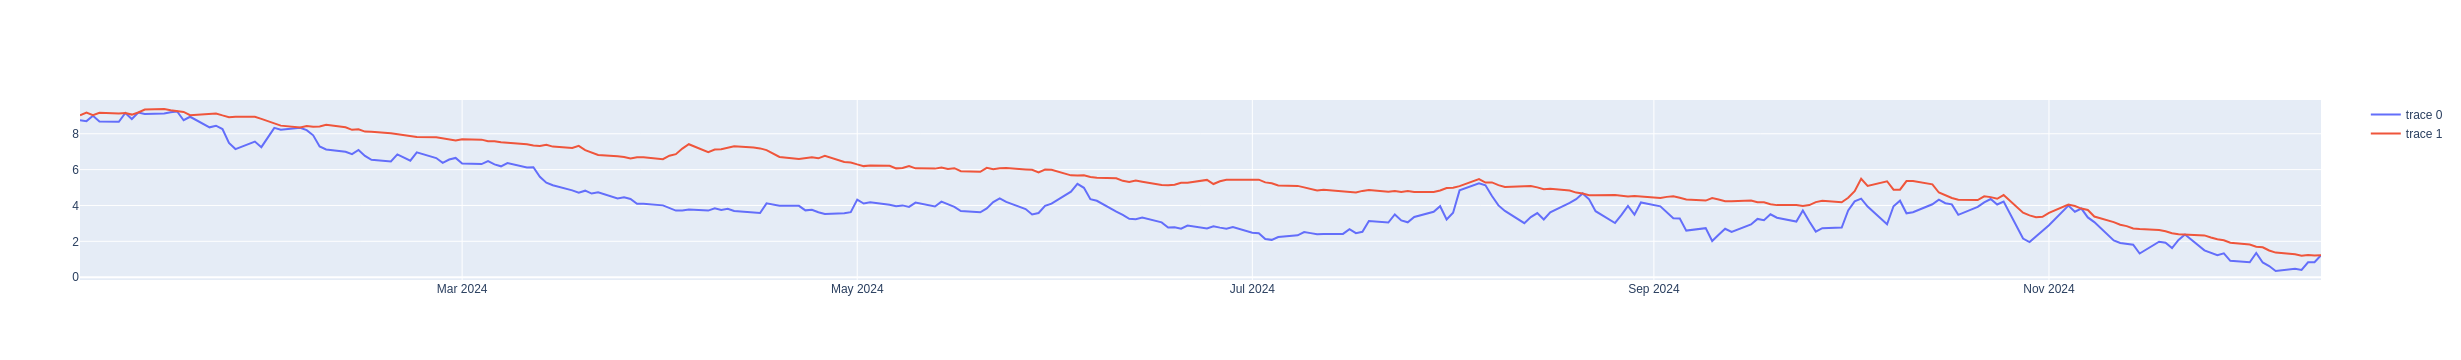

In [103]:
# https://plotly.com/python/line-and-scatter/
# Alternative
#fig = px.scatter(df_time_value, x="datetime", y="time_value")
#fig.show()
data = [go.Scatter(x=df_time_value_strike['datetime'].to_list(), y=df_time_value_strike['time_value'].to_list(),mode='lines'),
        go.Scatter(x=df_time_value_atm['datetime'].to_list(), y=df_time_value_atm['time_value'].to_list(),mode='lines')
       ] # markers, lines
iplot(data)

## Нелинейность опционов

In [122]:
atm_strike_df = df_opt_chain[df_opt_chain['strike'] == atm_strike]
atm_strike_row = atm_strike_df[atm_strike_df['type']==option_pricer.OptionType.CALL.code].iloc[0]
atm_strike_df

,datetime,expiration_date,contract_month,strike,mny,log_mny,type,premium,volume,open_interest,underlying_price,dte,tte,iv,delta,...,theta,rate,futures_symbol,future_id,underlying_expiration_date,year,mny_sd,settle,iv_settle,sd,root_id,contact_size,intrinsic_value,time_value,money_status
194,2024-12-13,2024-12-23,25G,74.5,1.000134,0.000134,c,1.221633,813,4156,74.49,10,0.027397,0.249375,0.506936,...,-0.061322,0.04407,BRN25G,COM.BRN/G25,2024-12-30,NaN,0.003256,1.22,0.249134,NaN,COM.BRN_BRN,1000.0,0.00,1.221633,atm
195,2024-12-13,2024-12-23,25G,74.5,1.000134,0.000134,p,1.231635,240,837,74.49,10,0.027397,0.249375,-0.493064,...,-0.061322,0.04407,BRN25G,COM.BRN/G25,2024-12-30,NaN,0.003256,1.23,0.249134,NaN,COM.BRN_BRN,1000.0,0.01,1.221635,atm


In [133]:
future_price = atm_strike_row['underlying_price']
option_price = atm_strike_row['premium']
contract_size = atm_strike_row['contact_size']
# atm_strike = atm_strike_row['strike']
future_price, option_price, atm_strike

(np.float64(74.49), np.float64(1.2216333415807057), np.float64(74.5))

In [132]:
prices = [price for price in range(int(future_price-25), int(future_price + 25))]
df_trades = pd.DataFrame({'underlying_price': prices, 'future_pnl': [price * contract_size] for price in prices], 'option_pnl': []})
df_trades

ValueError: All arrays must be of the same length

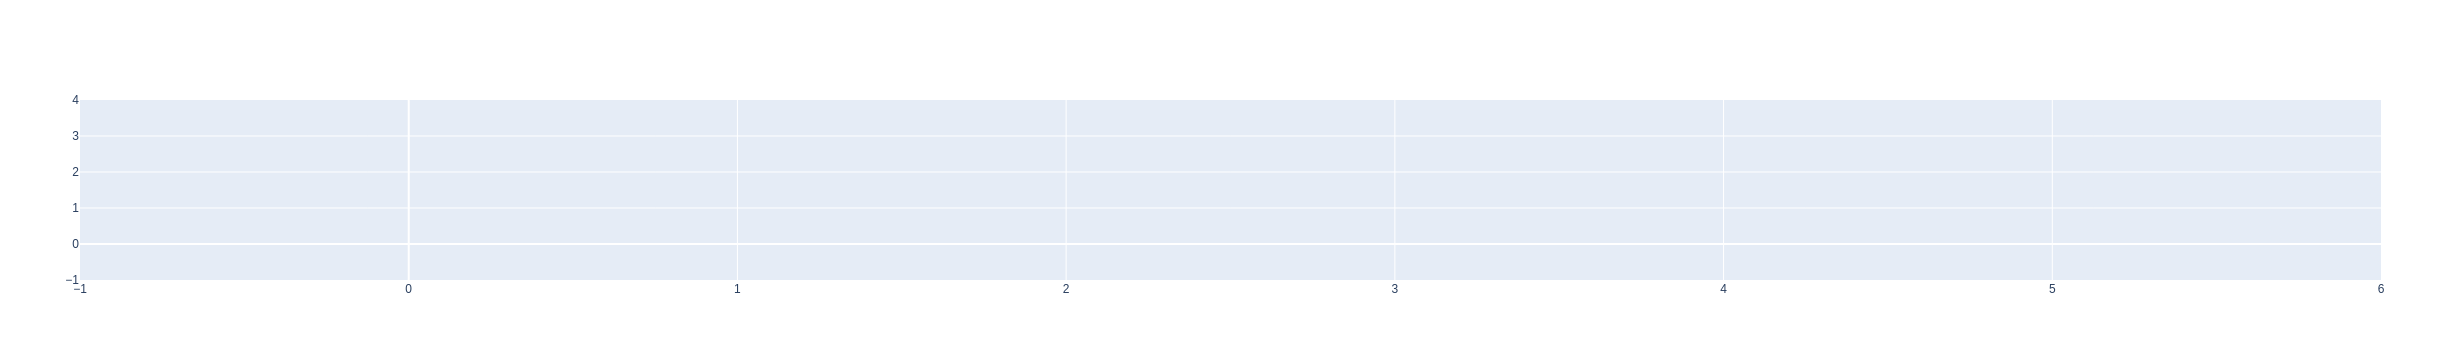

In [129]:
data = [go.Scatter(x=df_trades['underlying_price'].to_list(), y=df_trades['future_pnl'].to_list(),mode='lines'),
        go.Scatter(x=df_trades['underlying_price'].to_list(), y=df_trades['option_pnl'].to_list(),mode='lines')
       ] # markers, lines
iplot(data)